# Sensitivity analysis for the cutoff value of IC80 used in data classification 

Addressing the question: How sensitive are this model's conclusions to the choice of the 1 ug/mL IC80 cutoff that defines if a given strain is "sensitive" vs. "resistant"?

This notebook looks at the **data the cutoff is applied to**. If the IC80 distribution has a sparse, flat region around 1 ug/mL, the labels would be robust and small cutoff changes would reclassify relatively few strains. If the cutoff sits on a dense slope, the labels (and everything downstream) in the model would be fragile (more sensitive to the classification value itself).

**In the model pipeline, this cutoff lives in the Jupyter Notebook** `jupyter_notebook/preprocessing.ipynb`, config cell (`CUTOFF_LABEL`) and the labeling line:

```python
label_df['Label'] = np.array(label_df["pIC80"] > CUTOFF_LABEL, dtype=int)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

pd.set_option("display.width", 120)

First, going to re-derive the pIC80 cutoff value for VRC01 with the same function and constants as `preprocessing.ipynb` so this notebook is accurate to the actual model pipeline.

In [2]:
BNAB      = "VRC01"
BNAB_MW   = 145870        # g/mol, VRC01 IgG
LABEL_NAME = "IC80"
CUTOFF_UGML = 1.0         # ug/mL — the value under test

INFO_FILE   = f"../data/input_info_{BNAB}_{LABEL_NAME}.csv"
CATNAP_FILE = f"../data/{BNAB}_catnap.csv"


def convert_ic_to_pic(ic_values, mw_g_mol=BNAB_MW):
    """Returns: An array of pIC50 or 80.  (copied verbatim from preprocessing.ipynb)"""
    pic_array = pd.to_numeric(np.array(ic_values), errors="coerce")
    ic_g_l = pic_array * 1e-3
    ic_molar = ic_g_l / mw_g_mol
    pic_array = np.round(-np.log10(ic_molar), 2)
    return pic_array


CUTOFF_PIC = round(float(convert_ic_to_pic(CUTOFF_UGML)), 2)
print(f"Cutoff: IC80 < {CUTOFF_UGML} ug/mL   <=>   pIC80 > {CUTOFF_PIC}")

Cutoff: IC80 < 1.0 ug/mL   <=>   pIC80 > 8.16


**Next, loading the viral strains that are input into the model:** `input_info_VRC01_IC80.csv` contains the 889 strains that have both a usable sequence and a CATNAP neutralization record. These are the rows whose labels the model trains on, so this is the population the cutoff question addresses.

In [8]:
info = pd.read_csv(INFO_FILE)

# Re-derive the numeric IC80 the same way preprocessing does. Values that cannot
# be coerced (e.g. "UD" = undetermined) become NaN here.
info["IC80_num"] = pd.to_numeric(info[LABEL_NAME], errors="coerce")
info["measured"] = info["IC80_num"].notna()

n_total    = len(info)
n_measured = int(info["measured"].sum())
n_unmeas   = n_total - n_measured

print(f"Strains in modeling set        : {n_total}")
print(f"  with a numeric IC80          : {n_measured}")
print(f"  without ('UD', undetermined) : {n_unmeas}  ({n_unmeas / n_total:.1%})")
print()
print("Label balance as shipped (1 ug/mL IC80 cutoff):")
print(info["Label"].value_counts().rename({0: "0 = resistant", 1: "1 = sensitive"}).to_string())

Strains in modeling set        : 889
  with a numeric IC80          : 746
  without ('UD', undetermined) : 143  (16.1%)

Label balance as shipped (1 ug/mL IC80 cutoff):
Label
0 = resistant    583
1 = sensitive    306


**NOTE:** In `preprocessing.ipynb` the line

```python
label_df.loc[label_df["pIC80"].isna(), "pIC80"] = 0
```

sets every unparseable IC80 to `pIC80 = 0`. Since `0 > 8.16` is False, all of those strains are labeled resistant. They carry no measurement at all, so no choice of cutoff can move them. All 146 UD rows are entirely right-censored, with thresholds of >10, >25, >50 or >100 ug/mL (i.e. VRC01 failed to reach 80% neutralization at the highest concentration tested). 

Every one of those thresholds is at least 10x the 1 ug/mL cutoff, so labeling them resistant is correct, and the cell below quantifies how much of the resistant class they make up.

In [4]:
unmeasured_in_class0 = int(((~info["measured"]) & (info["Label"] == 0)).sum())
unmeasured_in_class1 = int(((~info["measured"]) & (info["Label"] == 1)).sum())
n_class0 = int((info["Label"] == 0).sum())

print(f"Unmeasured strains labeled resistant : {unmeasured_in_class0} "
      f"({unmeasured_in_class0 / n_class0:.1%} of the resistant class)")
print(f"Unmeasured strains labeled sensitive : {unmeasured_in_class1}")
print()
print(f"=> Only {n_measured} of {n_total} strains ({n_measured / n_total:.1%}) "
      f"have a label the cutoff can actually influence.")

Unmeasured strains labeled resistant : 143 (24.5% of the resistant class)
Unmeasured strains labeled sensitive : 0

=> Only 746 of 889 strains (83.9%) have a label the cutoff can actually influence.


**The distribution of IC80 values, plotting the 746 datapoints for strains with numerical IC80 values:**
- **Left** — the distribution itself, as a histogram on a log IC80 axis, split at the cutoff
- **Right** — every strain as one point, rank-ordered by potency, with the cutoff as a horizontal dashed line. 

IC80 spans several orders of magnitude, so both use a log scale.

VRC01 IC80 and the 1 ug/mL labeling cutoff (n=746 measured strains; 143 'UD' excluded)


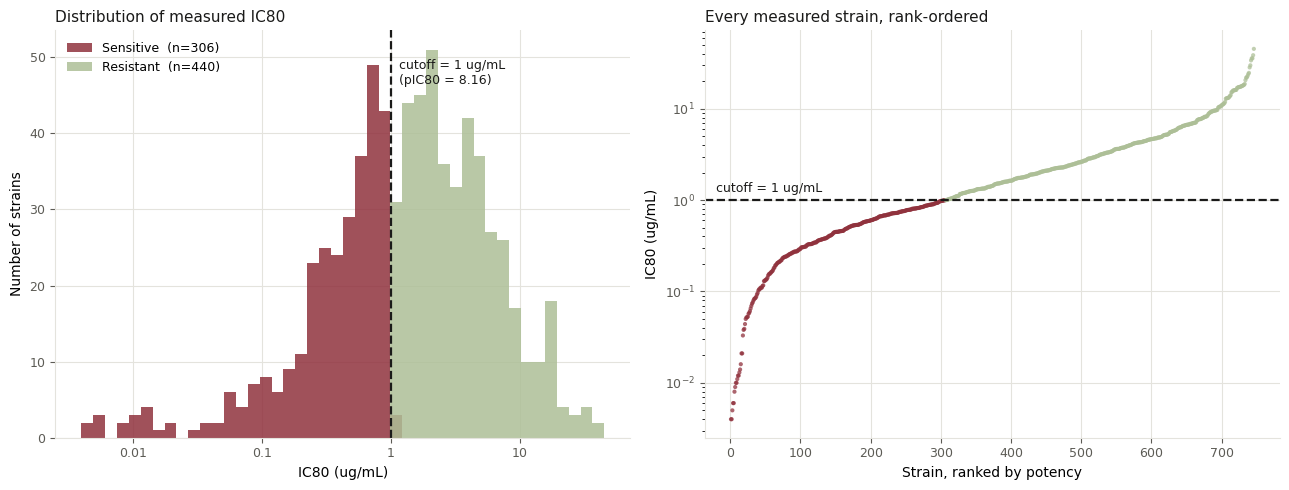

In [11]:
BLUE, ORANGE = "#90323D", "#ADBF97"      # categorical slots 1 and 2
INK, MUTED, GRID = "#1a1a19", "#5c5b55", "#e4e3dd"

m = info.loc[info["measured"]].copy()
log_ic80 = np.log10(m["IC80_num"])
is_sens  = m["IC80_num"] < CUTOFF_UGML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: distribution --------------------------------------------------
bins = np.linspace(log_ic80.min(), log_ic80.max(), 45)
ax1.hist(log_ic80[is_sens],  bins=bins, color=BLUE,   alpha=0.85,
         label=f"Sensitive  (n={int(is_sens.sum())})")
ax1.hist(log_ic80[~is_sens], bins=bins, color=ORANGE, alpha=0.85,
         label=f"Resistant  (n={int((~is_sens).sum())})")
ax1.axvline(np.log10(CUTOFF_UGML), color=INK, linestyle="--", linewidth=1.6)
ax1.annotate(f"cutoff = {CUTOFF_UGML:g} ug/mL\n(pIC80 = {CUTOFF_PIC})",
             xy=(np.log10(CUTOFF_UGML), ax1.get_ylim()[1] * 0.93),
             xytext=(6, 0), textcoords="offset points",
             color=INK, fontsize=9, va="top")
ax1.set_xlabel("IC80 (ug/mL)")
ax1.set_ylabel("Number of strains")
ax1.set_title("Distribution of measured IC80", color=INK, fontsize=11, loc="left")
ax1.legend(frameon=False, fontsize=9, loc="upper left")

# ---- Right: rank-ordered, horizontal cutoff ------------------------------
order = np.argsort(m["IC80_num"].values)
rank = np.arange(1, len(order) + 1)
ax2.scatter(rank, m["IC80_num"].values[order], s=9,
            c=np.where(is_sens.values[order], BLUE, ORANGE), alpha=0.75,
            linewidths=0)
ax2.set_yscale("log")
ax2.axhline(CUTOFF_UGML, color=INK, linestyle="--", linewidth=1.6)
ax2.annotate(f"cutoff = {CUTOFF_UGML:g} ug/mL", xy=(0.02, CUTOFF_UGML),
             xycoords=("axes fraction", "data"), xytext=(0, 6),
             textcoords="offset points", color=INK, fontsize=9)
ax2.set_xlabel("Strain, ranked by potency")
ax2.set_ylabel("IC80 (ug/mL)")
ax2.set_title("Every measured strain, rank-ordered", color=INK, fontsize=11, loc="left")

for ax in (ax1, ax2):
    ax.grid(True, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

# Label the log-IC80 axis in real units rather than exponents.
ticks = np.array([-3, -2, -1, 0, 1, 2])
ticks = ticks[(ticks >= log_ic80.min()) & (ticks <= log_ic80.max())]
ax1.xaxis.set_major_locator(FixedLocator(ticks))
ax1.set_xticklabels([f"{10.0**t:g}" for t in ticks])

print(f"{BNAB} IC80 and the 1 ug/mL labeling cutoff (n={n_measured} measured strains; {n_unmeas} 'UD' excluded)")

fig.tight_layout()
plt.show()

Now, *quantify* where the cutoff falls. For a set of candidate cutoffs around 1 ug/mL, how many strains change their classification?

In [9]:
rows = []
for c in [0.7, 0.8, 
          0.9, 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98, 0.99,
          1.0, 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
          1.1, 1.2]:
    new_label = (m["IC80_num"] < c).astype(int)
    flipped = int((new_label != is_sens.astype(int)).sum())
    rows.append({
        "cutoff (ug/mL)": c,
        "pIC80": round(float(convert_ic_to_pic(c)), 2),
        "n sensitive": int(new_label.sum()),
        "n resistant (measured)": int(len(m) - new_label.sum()),
        "reclassified vs. 1.0": flipped,
        "% of measured": f"{flipped / len(m):.1%}",
    })

pd.DataFrame(rows)

,cutoff (ug/mL),pIC80,n sensitive,n resistant (measured),reclassified vs. 1.0,% of measured
0,0.70,8.32,227,519,79,10.6%
1,0.80,8.26,258,488,48,6.4%
2,0.90,8.21,288,458,18,2.4%
3,0.91,8.20,290,456,16,2.1%
4,0.92,8.20,291,455,15,2.0%
5,0.93,8.20,293,453,13,1.7%
6,0.94,8.19,296,450,10,1.3%
7,0.95,8.19,296,450,10,1.3%
8,0.96,8.18,297,449,9,1.2%
9,0.97,8.18,298,448,8,1.1%
